# Machine Learning Basic Template

End-to-end starter notebook: import → load → EDA → feature engineering → feature selection → split → scaling → modeling (regression & classification) → evaluation.

Replace `df`, `target`, and column lists with your actual dataset details.

## 1. Import Libraries

In [70]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [71]:
# Load your dataset (CSV / Excel / SQL etc.)
df = pd.read_csv(r'C:\AHAMMED\BIA_DATA_SCIENCE\FIRST_PROJECT\MACHINE_LEARNING\DATASET\Housing.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. Exploratory Data Analysis (EDA)

Basic structure, types, summary stats, and missing values before any deeper analysis.

In [72]:
print("Shape:", df.shape)
df.info()

Shape: (545, 13)
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [73]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.0,NaN,NaN,NaN,4766729.247706,1870439.615657,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,NaN,NaN,NaN,5150.541284,2170.141023,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,NaN,NaN,NaN,2.965138,0.738064,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,NaN,NaN,NaN,1.286239,0.50247,1.0,1.0,1.0,2.0,4.0
stories,545.0,NaN,NaN,NaN,1.805505,0.867492,1.0,1.0,2.0,2.0,4.0
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
# Missing values overview
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0


In [75]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### 3.1 Univariate Analysis

Distribution of each variable on its own — histograms for numeric columns, count plots for categorical columns.

In [76]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


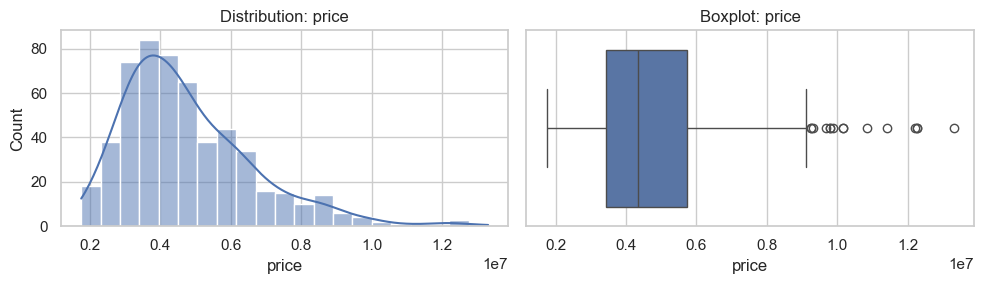

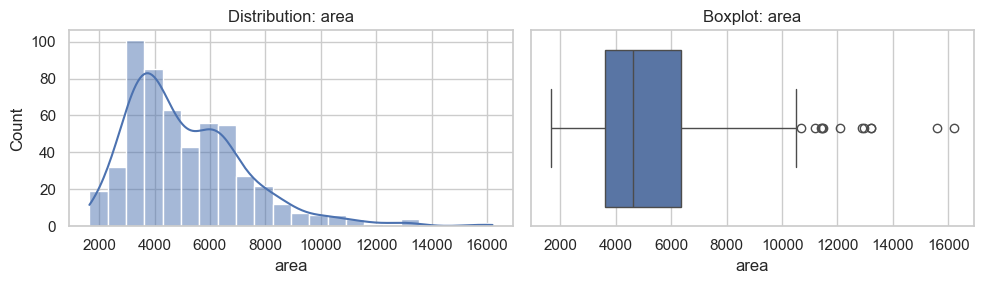

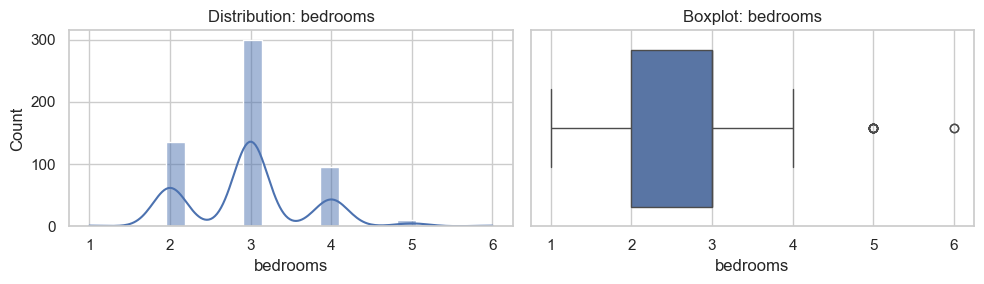

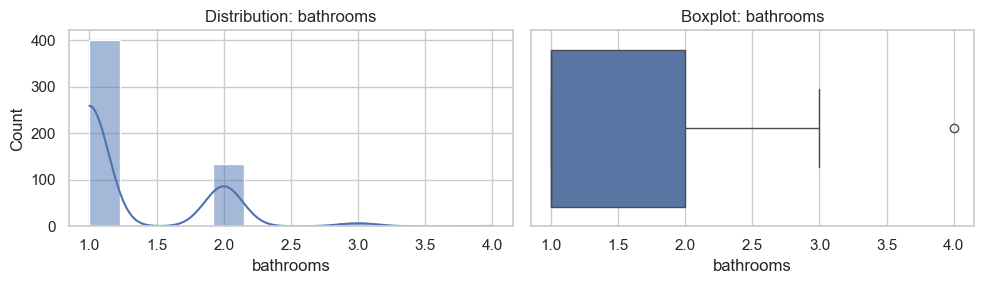

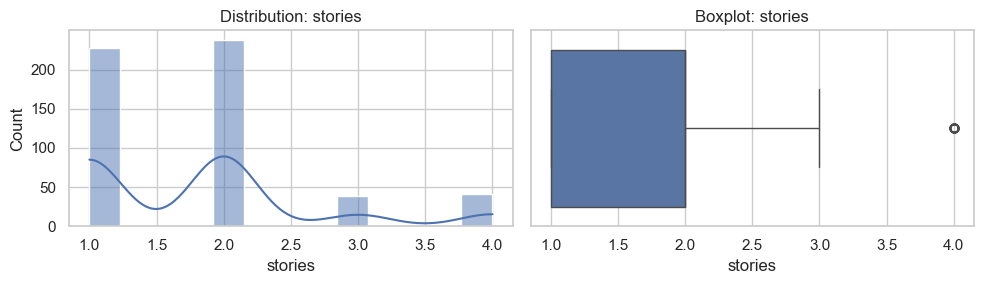

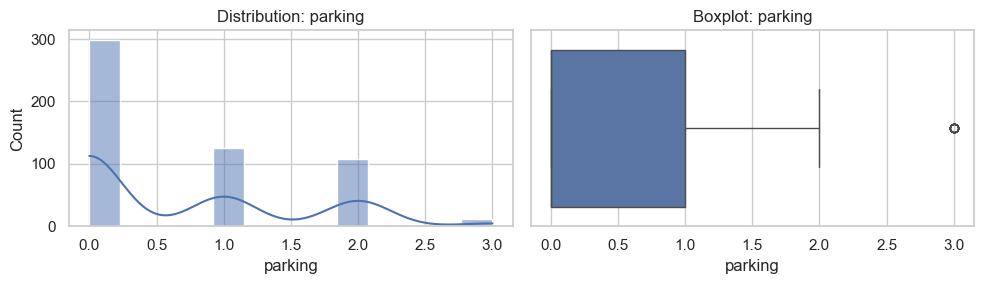

In [77]:
# Numeric: histograms + boxplots
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution: {col}")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

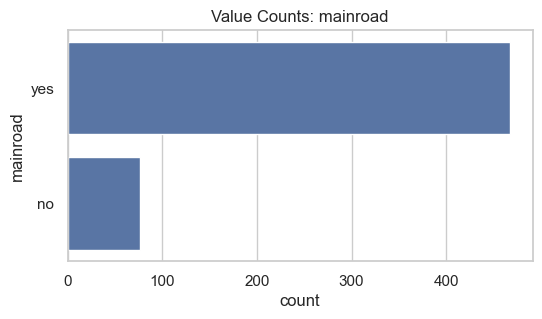

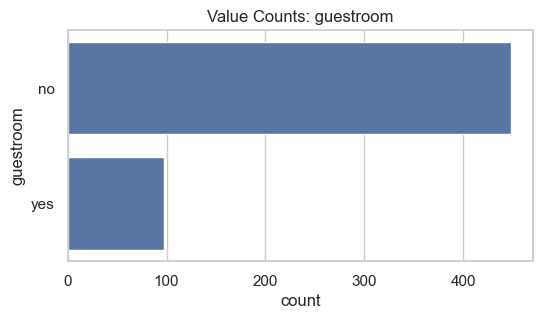

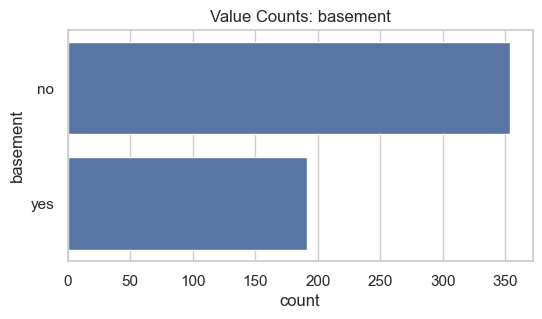

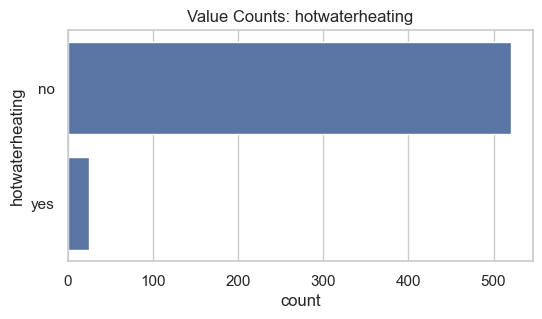

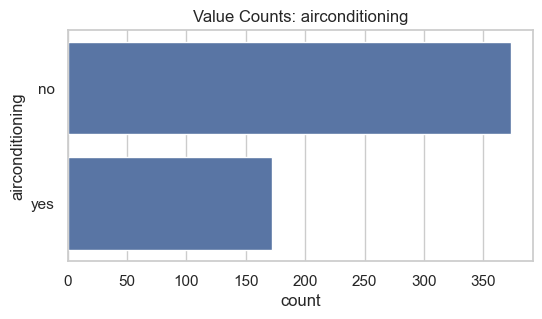

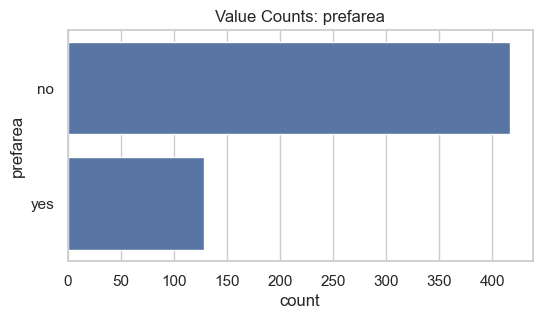

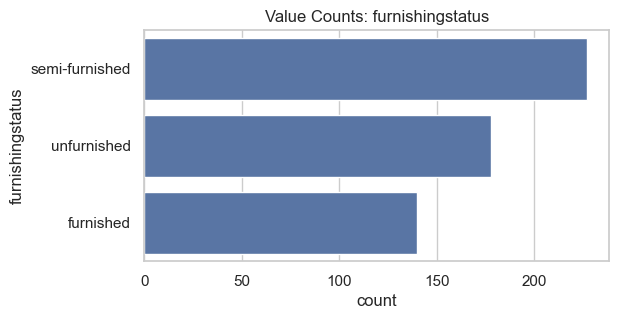

In [78]:
# Categorical: count plots
for col in cat_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Value Counts: {col}")
    plt.show()

### 3.2 Bivariate Analysis

Relationship between each feature and the target, plus pairwise relationships among numeric features.

In [79]:
target = "target_column"  # set your target column name

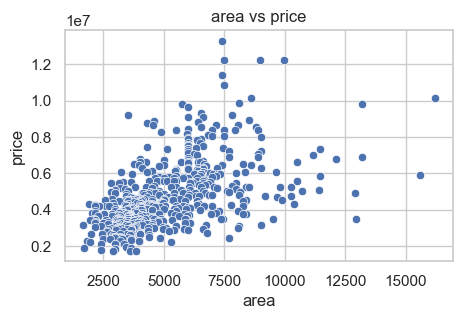

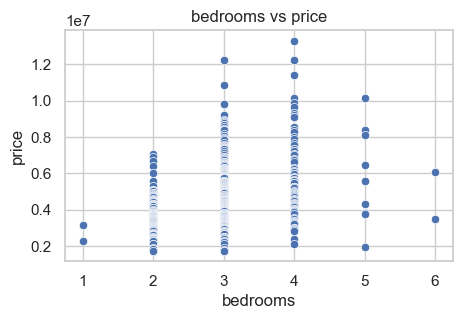

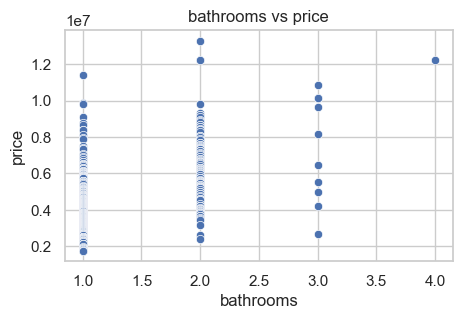

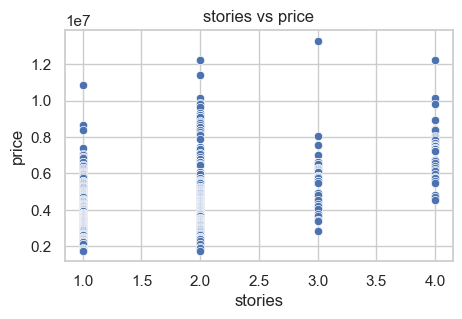

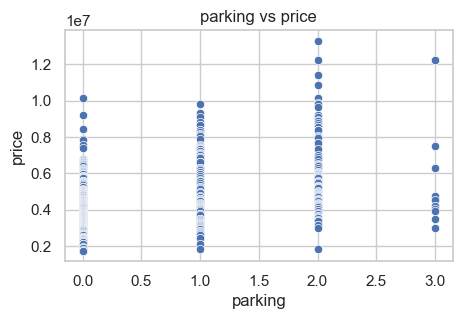

In [80]:
# Numeric feature vs numeric/continuous target
target = "price"

for col in num_cols:
    if col != target:
        plt.figure(figsize=(5, 3))
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()

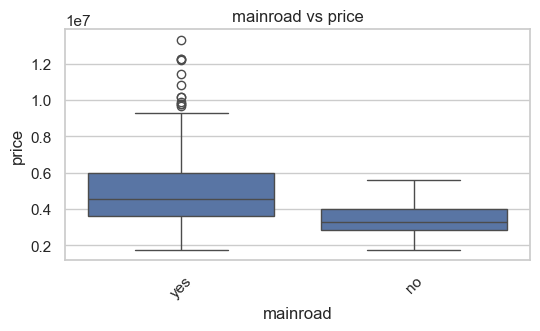

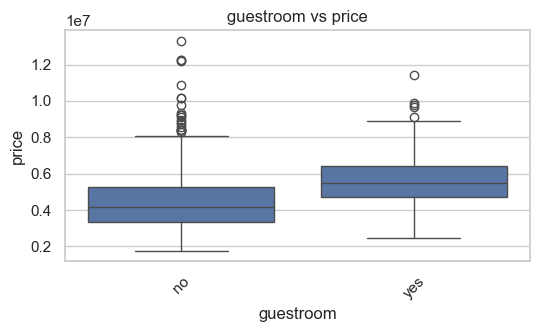

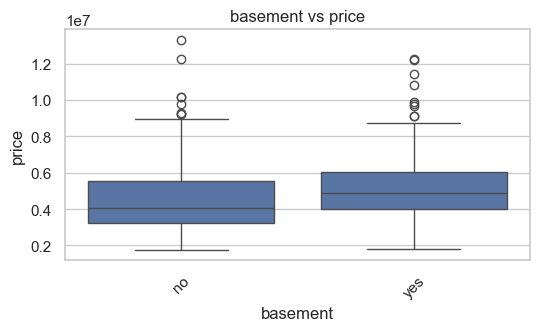

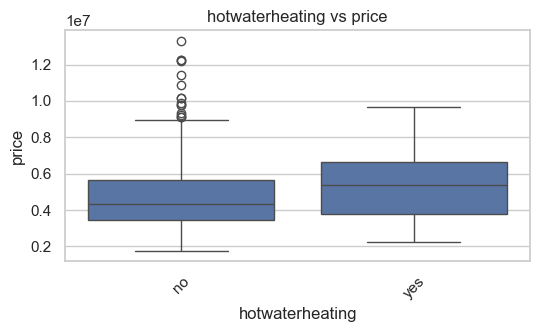

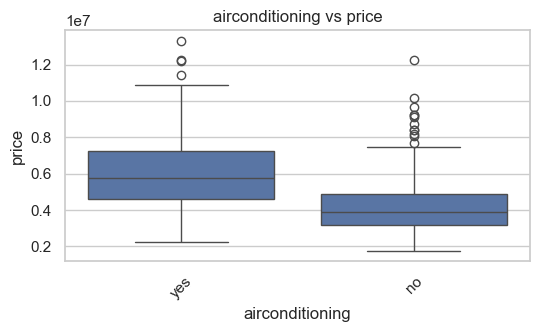

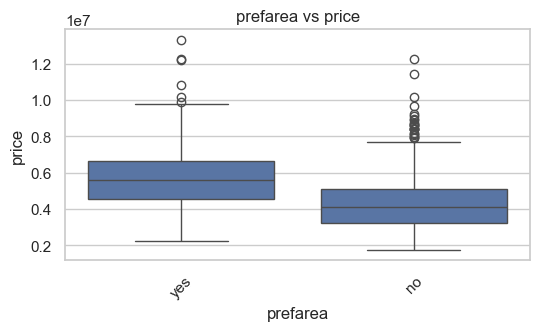

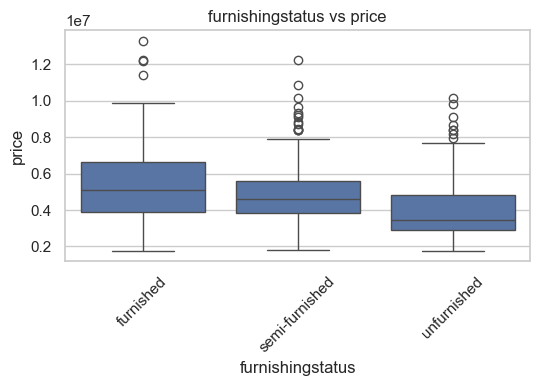

In [81]:
# Categorical feature vs target (boxplot, useful for regression target)
for col in cat_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()

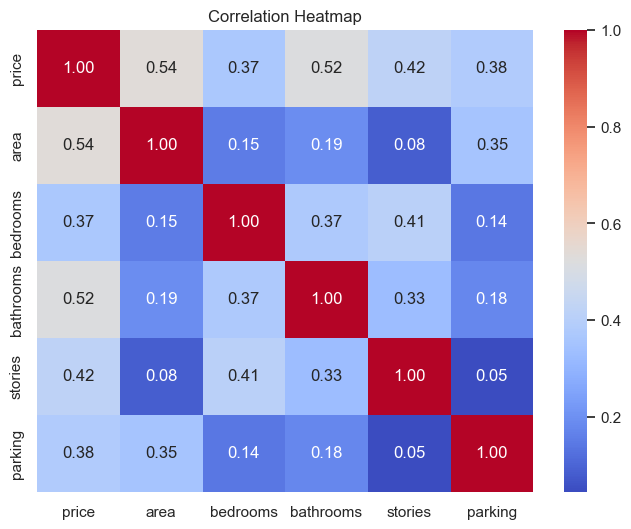

In [82]:
# Correlation heatmap (numeric features)
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

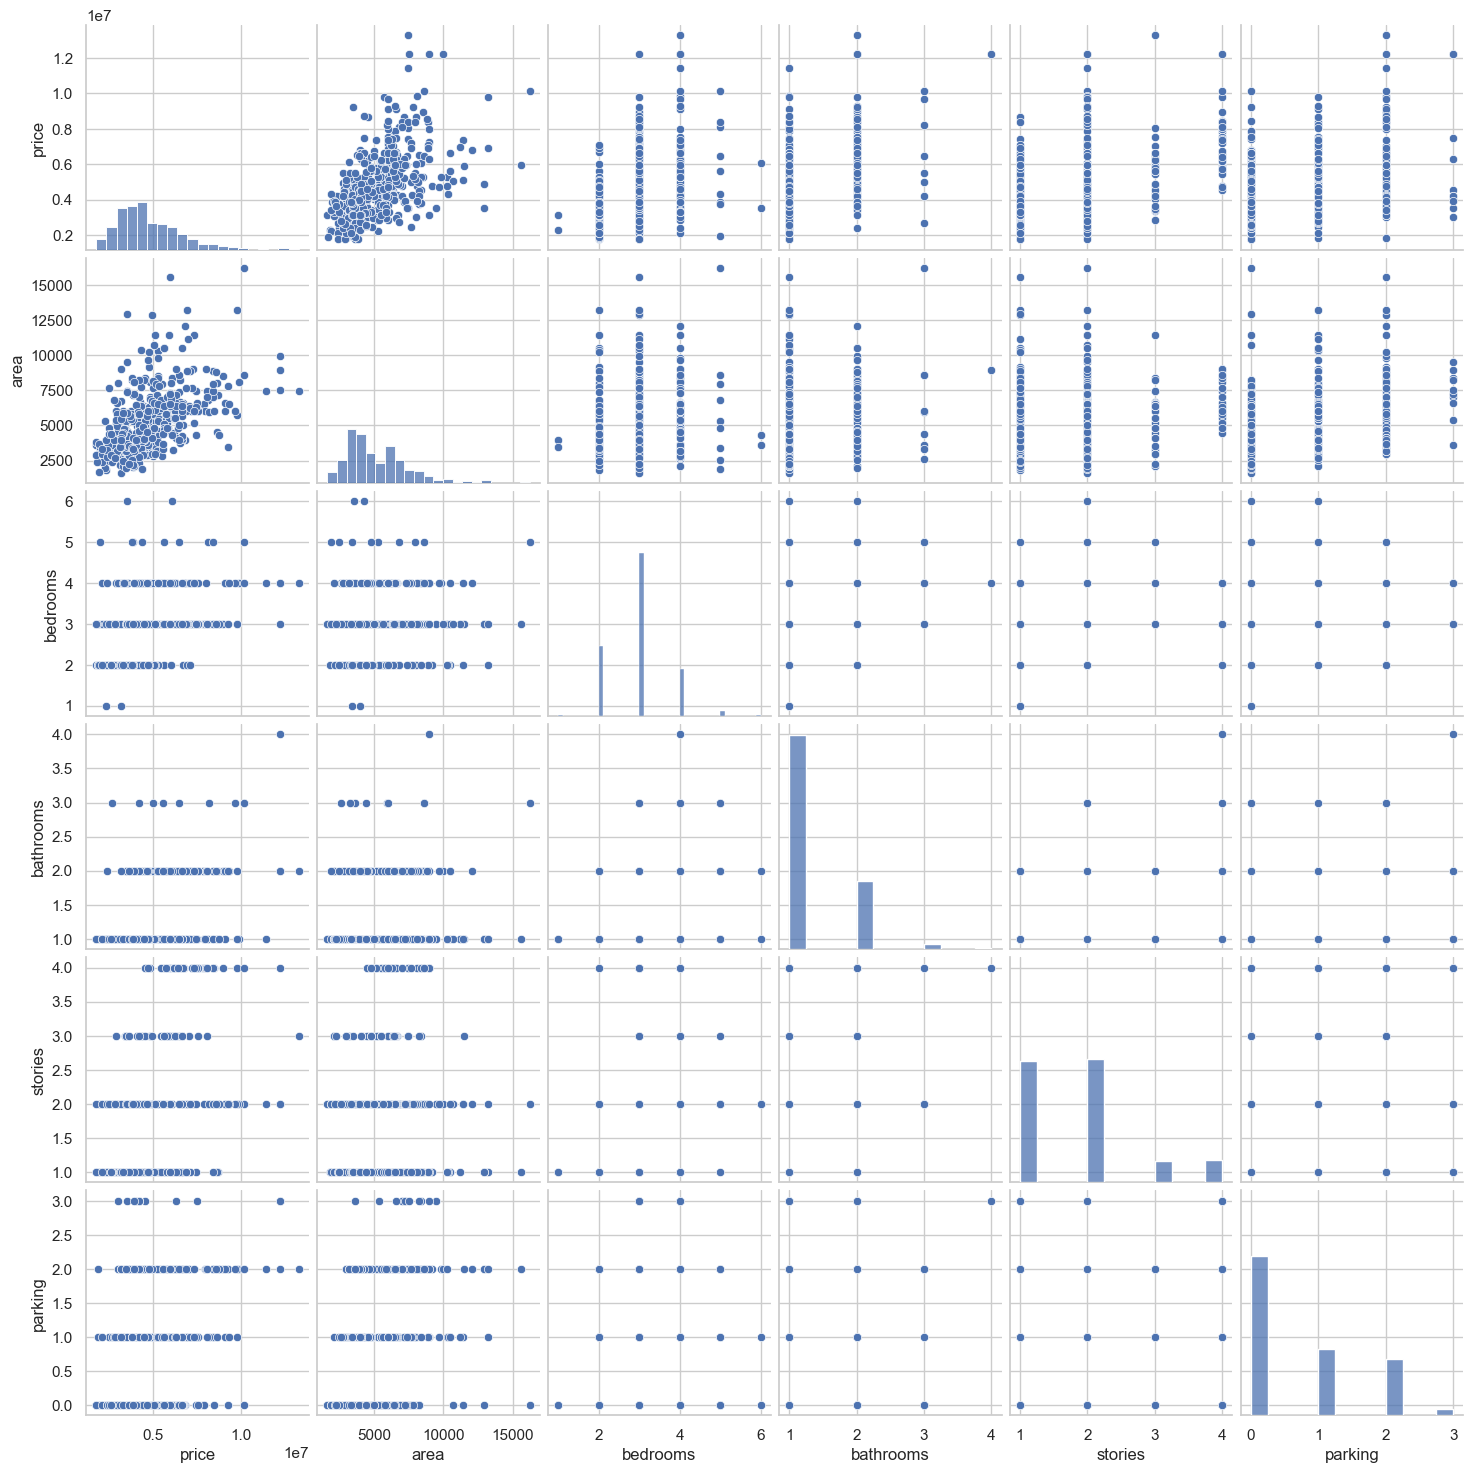

In [83]:
# Pairplot for a quick multi-variable view (sample if dataset is large)
sns.pairplot(df[num_cols].sample(min(500, len(df))))
plt.show()

## 4. Feature Engineering

### 4.1 Missing Value Treatment

Common strategies: drop, mean/median (numeric), mode (categorical), or model-based imputation.

In [84]:
# Numeric: median imputation
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical: mode imputation
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Alternative: drop rows/columns with too many missing values
# df = df.dropna(thresh=len(df) * 0.5, axis=1)   # drop columns with >50% missing
# df = df.dropna()                                # drop remaining rows with missing values

df.isnull().sum().sum()  # should be 0 after imputation

np.int64(0)

### 4.2 Outlier Treatment

IQR-based detection and capping (winsorizing). Adjust the multiplier as needed.

In [85]:
def cap_outliers_iqr(data, col, factor=1.5):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    data[col] = np.clip(data[col], lower, upper)
    return data

for col in num_cols:
    if col != target:
        df = cap_outliers_iqr(df, col)

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.102250e+03,2.005804e+03,1650.0,3600.0,4600.0,6360.0,10500.0
bedrooms,545.0,2.950459e+00,6.975039e-01,1.0,2.0,3.0,3.0,4.5
bathrooms,545.0,1.285321e+00,4.979417e-01,1.0,1.0,1.0,2.0,3.5
stories,545.0,1.767890e+00,7.775434e-01,1.0,1.0,2.0,2.0,3.5
parking,545.0,6.825688e-01,8.347732e-01,0.0,0.0,0.0,1.0,2.5


### 4.3 Encoding Categorical Variables

#### Simple / Label Mapping

Use when a column has an obvious manual mapping (e.g. binary Yes/No → 1/0).

In [86]:
# Example: manual map for a binary column
# df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

# Generic LabelEncoder (good for binary / target encoding, not ideal for nominal multi-class features)
le = LabelEncoder()
# df["binary_col"] = le.fit_transform(df["binary_col"])

#### One-Hot Encoding

Use for nominal categorical features with no inherent order.

In [87]:
# Encode binary categorical columns
binary_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# One-Hot Encode the remaining nominal column
df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True
)

#### Ordinal Encoding

Use for categorical features with a natural order (e.g. Low < Medium < High).

In [88]:
ordinal_cols = []  # e.g. ["education_level"]
ordinal_categories = []  # e.g. [["High School", "Bachelors", "Masters", "PhD"]]

# oe = OrdinalEncoder(categories=ordinal_categories)
# df[ordinal_cols] = oe.fit_transform(df[ordinal_cols])

## 5. Feature Selection

### 5.1 Correlation

Drop one of each pair of highly correlated features (multicollinearity reduction).

In [89]:
corr_matrix = df.select_dtypes(include=np.number).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.85
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print("Highly correlated columns to consider dropping:", to_drop)

# df = df.drop(columns=to_drop)

Highly correlated columns to consider dropping: []


### 5.2 Variance Inflation Factor (VIF)

VIF quantifies multicollinearity per feature. VIF > 5 (or 10) typically signals a problematic feature.

In [90]:
def calculate_vif(data, features):
    X = data[features].assign(intercept=1)
    vif_df = pd.DataFrame()
    vif_df["feature"] = features
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(features))]
    return vif_df.sort_values("VIF", ascending=False)

vif_features = [c for c in df.select_dtypes(include=np.number).columns if c != target]
vif_result = calculate_vif(df, vif_features)
vif_result

,feature,VIF
3,stories,1.513472
1,bedrooms,1.441784
0,area,1.369455
6,basement,1.312316
2,bathrooms,1.273420
9,parking,1.219068
5,guestroom,1.213975
8,airconditioning,1.197822
4,mainroad,1.170054
10,prefarea,1.154321


## 6. Train-Test Split

In [91]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (436, 13) Test shape: (109, 13)


## 7. Feature Scaling

### 7.1 Normalization (MinMaxScaler)

Scales features to a fixed range [0, 1]. Good when data isn't normally distributed or for distance-based models.

In [92]:
target = "price"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

### 7.2 Standardization (StandardScaler)

Centers data to mean 0, std 1. Preferred for linear models, SVM, PCA, etc.

In [93]:
std_scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = std_scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = std_scaler.transform(X_test[num_cols])

## 8. Model Building — Regression

Use when the target is continuous. Use `X_train_scaled` / `X_test_scaled` (or `_norm`) as appropriate for the model.

In [94]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)

In [95]:
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_reg.predict(X_test_scaled)

In [96]:
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_reg.predict(X_test_scaled)

In [97]:
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)  # tree-based models don't need scaling
y_pred_dt = dt_reg.predict(X_test)

In [98]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

### Regression Evaluation Metrics

In [99]:
def regression_report(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}\n")
    return {"model": model_name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

results = []
results.append(regression_report(y_test, y_pred_lin, "Linear Regression"))
results.append(regression_report(y_test, y_pred_ridge, "Ridge Regression"))
results.append(regression_report(y_test, y_pred_lasso, "Lasso Regression"))
results.append(regression_report(y_test, y_pred_dt, "Decision Tree Regressor"))
results.append(regression_report(y_test, y_pred_rf, "Random Forest Regressor"))

pd.DataFrame(results).sort_values("RMSE")

--- Linear Regression ---
MAE  : 980346.8169
MSE  : 1754676511779.8098
RMSE : 1324642.0316
R2   : 0.6529

--- Ridge Regression ---
MAE  : 979771.1748
MSE  : 1754715596728.9607
RMSE : 1324656.7845
R2   : 0.6528

--- Lasso Regression ---
MAE  : 980346.7729
MSE  : 1754676579939.7744
RMSE : 1324642.0573
R2   : 0.6529

--- Decision Tree Regressor ---
MAE  : 1233798.1651
MSE  : 2908898711009.1743
RMSE : 1705549.3869
R2   : 0.4245

--- Random Forest Regressor ---
MAE  : 1014817.9365
MSE  : 1968803027225.8401
RMSE : 1403140.4161
R2   : 0.6105



,model,MAE,MSE,RMSE,R2
0,Linear Regression,9.803468e+05,1.754677e+12,1.324642e+06,0.652853
2,Lasso Regression,9.803468e+05,1.754677e+12,1.324642e+06,0.652853
1,Ridge Regression,9.797712e+05,1.754716e+12,1.324657e+06,0.652846
4,Random Forest Regressor,1.014818e+06,1.968803e+12,1.403140e+06,0.610491
3,Decision Tree Regressor,1.233798e+06,2.908899e+12,1.705549e+06,0.424501


## 9. Model Building — Classification

Use when the target is categorical. Use `X_train_scaled` / `X_test_scaled` (or `_norm`) as appropriate for the model.

In [100]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

In [101]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dtc = dt_clf.predict(X_test)

In [102]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rfc = rf_clf.predict(X_test)
y_prob_rfc = rf_clf.predict_proba(X_test)[:, 1]

In [103]:
svm_clf = SVC(kernel="rbf", probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)

### Classification Evaluation Metrics

In [104]:
def classification_report_summary(y_true, y_pred, model_name="Model", y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"--- {model_name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")

    auc = None
    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC   : {auc:.4f}")

    print()
    return {"model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC_AUC": auc}

clf_results = []
clf_results.append(classification_report_summary(y_test, y_pred_log, "Logistic Regression", y_prob_log))
clf_results.append(classification_report_summary(y_test, y_pred_dtc, "Decision Tree Classifier"))
clf_results.append(classification_report_summary(y_test, y_pred_rfc, "Random Forest Classifier", y_prob_rfc))
clf_results.append(classification_report_summary(y_test, y_pred_svm, "SVM Classifier"))

pd.DataFrame(clf_results).sort_values("F1", ascending=False)

--- Logistic Regression ---
Accuracy  : 0.0000
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000


ValueError: multi_class must be in ('ovo', 'ovr')

In [ ]:
# Confusion matrix (example: best/last model)
cm = confusion_matrix(y_test, y_pred_rfc)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_rfc))

In [ ]:
# ROC curve (example: Random Forest)
fpr, tpr, _ = roc_curve(y_test, y_prob_rfc)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rfc):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 10. Save Model (joblib)

Persist the trained model (and scaler, since predictions on new data must be scaled the same way) to disk for later reuse.

In [ ]:
import joblib

# --- Save a regression model ---
joblib.dump(rf_reg, "rf_regressor.joblib")
joblib.dump(std_scaler, "scaler_regression.joblib")  # save the scaler used for this model's inputs

print("Saved: rf_regressor.joblib, scaler_regression.joblib")

In [ ]:
# --- Save a classification model ---
joblib.dump(rf_clf, "rf_classifier.joblib")
joblib.dump(std_scaler, "scaler_classification.joblib")

print("Saved: rf_classifier.joblib, scaler_classification.joblib")

### Load Model (for reuse)

In [ ]:
# Load back later in a new session
loaded_model = joblib.load("rf_regressor.joblib")   # or rf_classifier.joblib
loaded_scaler = joblib.load("scaler_regression.joblib")

# Example prediction on new data (X_new must have the same columns as X_train)
# X_new_scaled = X_new.copy()
# X_new_scaled[num_cols] = loaded_scaler.transform(X_new[num_cols])
# loaded_model.predict(X_new_scaled)